# Phase 3A: Weekly Recommendation Engine

## Learning Objectives
1. **Integrate** Phase 1 (prize money) + Phase 2 (predictions) into one system
2. **Build a practical tool** for weekly lineup decisions
3. **Track golfer usage** (3 uses per player limit)
4. **Generate recommendations** with Expected Value rankings
5. **Handle edge cases** (alternate picks, usage limits, field changes)

## Real-World Application
This is what you'll use **every Thursday** before tournaments start:
- Input: This week's field and tournament details
- Output: Top 3 picks + alternate, ranked by Expected Value
- Considers: Current form, purse size, usage remaining, field strength

In [1]:
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

sns.set_style('darkgrid')
plt.rcParams['figure.figsize'] = (14, 7)

print("✅ Libraries loaded!")

✅ Libraries loaded!


## Step 1: Load Your Trained Models

**Software Engineering Concept: Model Persistence**

We saved our models in Phase 2 using `pickle`. Now we load them back.
This is how production ML systems work - train once, use many times!

In [2]:
# Load models from Phase 2
with open('rf_win_model.pkl', 'rb') as f:
    rf_win = pickle.load(f)
    
with open('rf_top5_model.pkl', 'rb') as f:
    rf_top5 = pickle.load(f)
    
with open('model_features.pkl', 'rb') as f:
    features = pickle.load(f)

print("✅ Models loaded successfully!")
print(f"\nFeatures required: {len(features)}")
print(features)

✅ Models loaded successfully!

Features required: 12
['strokes_gained_total_avg_tz_roll3', 'strokes_gained_tee_to_green_avg_tz_roll3', 'strokes_gained_putting_avg_tz_roll3', 'strokes_gained_off_the_tee_avg_tz_roll3', 'strokes_gained_approach_the_green_avg_tz_roll3', 'strokes_gained_around_the_green_avg_tz_roll3', 'strokes_gained_total_avg_tz_vol3', 'strokes_gained_putting_avg_tz_vol3', 'strokes_gained_total_avg_tz_roll5', 'field_strength', 'birdie_to_bogey_ratio_value_tz_roll3', 'cut_rate_r5']


## Step 2: Load Prize Money Model

Load the payout model from Phase 1 so we can convert finish probabilities to dollars.

In [3]:

#Load payout model from Phase 1

try:
    payout_model = pd.read_csv("payout_model.csv")
    print("✅ Payout model loaded!")
    print(f"\nPayout data for {payout_model['tournament_type'].nunique()} tournament types")
    print(payout_model.groupby('tournament_type')['position_num'].count())
except FileNotFoundError:
    print("Payout model not found. We'll use simplified estimates.")
    #Create simplified payout model
    positions = range(1,71)
    payout_model = pd.DataFrame({
        'position_num': list(positions) * 3,
        'tournament_type': ['Major']*70 + ['Elevated'] * 70 + ['Regular'] * 70,
        'pct_of_purse': [18, 10.8, 6.8, 5, 4.2, 3.6, 3.35, 3.1, 2.9, 2.65] + [2.4]*10 + [1.5]*10 + [1.0]*10 + [0.5]*30
    })
    print("Using simplified payout model.")
    


✅ Payout model loaded!

Payout data for 4 tournament types
tournament_type
Elevated    69
Major       51
Playoff     45
Regular     82
Name: position_num, dtype: int64


## Step 3: Load Player Data and Calculate Current Form

We need each player's most recent stats to make predictions.

In [4]:


df = pd.read_csv("full_df.csv")
print(f"Loaded {len(df):,} records")
print(f"Players: {df['player_name'].nunique()}")
print(f"Tournaments: {df['tournament_name'].nunique()}")

# Get each player's most recent form (latest tournament they played)
# We'll use this as their "current" stats for predictions
df_sorted = df.sort_values(['player_name', 'year', 'tournament_name'])
latest_form = df_sorted.groupby('player_name').last().reset_index()


print(f"\n✅ Latest form data for {len(latest_form)} players")
print("\nSample:")
print(latest_form[['player_name', 'tournament_name', 'strokes_gained_total_avg_tz_roll3']].head(10))

Loaded 3,023 records
Players: 368
Tournaments: 44

✅ Latest form data for 368 players

Sample:
                 player_name                               tournament_name  \
0             Aaron Baddeley                          Wyndham Championship   
1                  Aaron Rai                          Wyndham Championship   
2                 Aaron Wise                                Rocket Classic   
3                Adam Hadwin  the Memorial Tournament presented by Workday   
4                Adam Schenk            World Wide Technology Championship   
5                 Adam Scott  the Memorial Tournament presented by Workday   
6              Adam Svensson            World Wide Technology Championship   
7  Adrien Dumont de Chassart                              Puerto Rico Open   
8             Adrien Saddier                         The Open Championship   
9              Akshay Bhatia  the Memorial Tournament presented by Workday   

   strokes_gained_total_avg_tz_roll3  
0      

## Step 4: Create Expected Value Calculator Function

**Core Algorithm: Expected Value Calculation**

This is the heart of your recommendation engine!

```
EV = Σ(P(finish_i) × prize_i)
```

We'll create buckets:
- Win (1st)
- Top-2 to Top-5
- Top-6 to Top-10
- Top-11 to Top-20
- Etc.

In [5]:
def calculate_expected_value(win_prob, top5_prob, top10_prob, purse, tournament_type, payout_model):
    """ 
    Calculate expected prize money for a golfer.
    
    Parameters:
    -----------
    win_prob : float
        Probability of winning (0-1)
    top5_prob : float
        Probability of top-5 finish (0-1)
    top10_prob : float
        Probability of top-10 finish (0-1)
    purse : float
        Total tournament purse in dollars
    tournament_type : str
        'Major', 'Elevated', or 'Regular'
    payout_model : DataFrame
        Payout percentage lookup table
    
    Returns:
    --------
    float : Expected value in dollars
    """
    #get averge payour percentages for different finish ranges
    def get_avg_payout_pct(positions, tourn_type):
        payouts = payout_model[
            (payout_model['position_num'].isin(positions)) & 
            (payout_model['tournament_type'] == tourn_type)
        ]['pct_of_purse'].mean()
        return payouts if not pd.isna(payouts) else 0 
    
    #calculate EV for different outcome buckets
    # these probabilities overlap, so we use conditional probabilities
    
    #win 
    win_payout_pct = get_avg_payout_pct([1], tournament_type)
    ev_win = win_prob * (win_payout_pct / 100) * purse
    
    #top-2 to 5 (no win)
    top5_not_win_prob = max(0, top5_prob - win_prob)
    top5_payout_pct = get_avg_payout_pct([2,3,4,5], tournament_type)
    ev_top5 = top5_not_win_prob * (top5_payout_pct / 100) * purse
    
    
    #top-6 to 10 (no top 5)
    top10_not_top5_prob = max(0, top10_prob - top5_prob)
    top10_payout_pct = get_avg_payout_pct([6,7,8,9,10], tournament_type)
    ev_top10 = top10_not_top5_prob * (top10_payout_pct / 100) * purse
    
    # Top-11 to Top-20 (conservative estimate for rest of field)
    rest_of_field_prob = max(0, 1 - top10_prob)
    rest_payout_pct = get_avg_payout_pct(range(11, 21), tournament_type)
    ev_rest = rest_of_field_prob * (rest_payout_pct / 100) * purse * 0.3  # Discounted
    
    total_ev = ev_win + ev_top5 + ev_top10 + ev_rest
    
    return total_ev
    
    
    
     
# Test the function
test_ev = calculate_expected_value(
    win_prob=0.10,
    top5_prob=0.35,
    top10_prob=0.55,
    purse=20_000_000,
    tournament_type='Elevated',
    payout_model=payout_model
)

print(f"Test EV calculation: ${test_ev:,.2f}")
print("\n✅ EV calculator function ready!")
     
    

Test EV calculation: $842,557.38

✅ EV calculator function ready!


## Step 5: Create Usage Tracker Class

**Software Engineering Concept: Object-Oriented Programming**

We need to track which golfers you've used and how many times.
A `class` is perfect for this - it bundles data (usage counts) with methods (check availability, use player).

In [6]:
class UsageTracker:
    """
    Tracks golfer usage throughout the season.
    Each golfer can be used a maximum of 3 times.
    """
    
    def __init__(self):
        """Initialize empty usage tracker"""
        self.usage = {} # Dictionary: player_name -> times_used
        self.max_uses = 3
        
    def use_player(self, player_name):
        """Record that a player was used."""
        if player_name not in self.usage:
            self.usage[player_name] = 0
        self.usage[player_name] += 1
    
    def get_uses(self, player_name):
        """Get how many times a player has been used."""
        return self.usage.get(player_name, 0)
    
    def uses_remaining(self, player_name):
        """Get how many uses remain for a plyer"""
        return self.max_uses - self.get_uses(player_name)
    
    def is_available(self, player_name):
        """Check if player can still be used."""
        return self.uses_remaining(player_name) > 0
    
    def get_summary(self):
        """Get summary of all player usage."""
        summary = pd.DataFrame([
            {'player': name, 'times_used': uses, 'remaining': self.max_uses - uses}
            for name, uses in self.usage.items()
        ]).sort_values('times_used', ascending=False)
        return summary
    
tracker = UsageTracker()

tracker.use_player('Scottie Scheffler')
tracker.use_player('Scottie Scheffler')
tracker.use_player('Rory McIlroy')

print('Test usage tracker:')
print(tracker.get_summary())

print(f"\nScottie available? {tracker.is_available('Scottie Scheffler')} (used {tracker.get_uses('Scottie Scheffler')} times)")
print("\n✅ Usage tracker ready!")


Test usage tracker:
              player  times_used  remaining
0  Scottie Scheffler           2          1
1       Rory McIlroy           1          2

Scottie available? True (used 2 times)

✅ Usage tracker ready!


## Step 6: Build the Weekly Recommendation Function

**THE MAIN EVENT!**

This function puts it all together:
1. Takes tournament field as input
2. Predicts win/top-5 probabilities for each player
3. Calculates Expected Value
4. Filters by usage availability
5. Ranks and returns top picks

In [7]:
def get_weekly_recommendations(field_df, purse, tournament_type, usage_tracker, rf_win_model, rf_top5_model,  top_n=10):
    
    """
    Generate weekly fantasy golf recommendations.
    
    Parameters:
    -----------
    field_df : DataFrame
        Player data with required features
    purse : float
        Tournament purse in dollars
    tournament_type : str
        'Major', 'Elevated', or 'Regular'
    usage_tracker : UsageTracker
        Current usage state
    rf_win_model : RandomForestClassifier
        Trained win prediction model
    rf_top5_model : RandomForestClassifier
        Trained top-5 prediction model
    top_n : int
        Number of recommendations to return
    
    Returns:
    --------
    DataFrame with recommendations ranked by Expected Value
    """
    
    valid_players = field_df.dropna(subset=features).copy()
    if len(valid_players) == 0:
        print("⚠️ No players with valid featur data!")
        return pd.DataFrame()
    
    X = valid_players[features]
    valid_players['win_prob'] = rf_win_model.predict_proba(X)[:,1]
    valid_players['top5_prob'] = rf_top5_model.predict_proba(X)[:,1]
    
    #Add top-10 model if you built one, otherwise estimate
    valid_players['top10_prob'] = valid_players['top5_prob'] * 1.5
    valid_players['top10_prob'] = valid_players['top10_prob'].clip(upper=0.95)
    
    #Calculate Expected Valude for each player
    
    valid_players['expected_value'] = valid_players.apply(
        lambda row: calculate_expected_value(
            win_prob=row['win_prob'],
            top5_prob=row['top5_prob'],
            top10_prob=row['top10_prob'],
            purse=purse,
            tournament_type=tournament_type,
            payout_model=payout_model
        ),
        axis=1
        
    )
    
    # Add usage information
    valid_players['times_used'] = valid_players['player_name'].apply(
        lambda name: usage_tracker.get_uses(name)
    )
    valid_players['uses_remaining'] = valid_players['player_name'].apply(
        lambda name: usage_tracker.uses_remaining(name)
    )
    valid_players['available'] = valid_players['uses_remaining'] > 0
    
    recommendations = valid_players[valid_players['available']].copy()
    recommendations = recommendations.sort_values('expected_value', ascending=False)
    # Select columns to display
    display_cols = [
        'player_name',
        'expected_value',
        'win_prob',
        'top5_prob',
        'strokes_gained_total_avg_tz_roll3',
        'times_used',
        'uses_remaining'
    ]
    
    return recommendations[display_cols].head(top_n).reset_index(drop=True)

print("✅ Recommendation function ready!")
    

✅ Recommendation function ready!


## Step 7: Test the Recommendation Engine

Let's simulate getting picks for a hypothetical tournament!

In [8]:
# YOUR TASK: Test the recommendation engine
# Use the latest_form data as if it's the field for an upcoming tournament

print("=" * 80)
print("🏌️ WEEKLY FANTASY GOLF RECOMMENDATIONS")
print("=" * 80)

# Tournament parameters
TOURNAMENT_NAME = "Hypothetical Championship"
PURSE = 20_000_000
TOURNAMENT_TYPE = "Elevated"

print(f"\nTournament: {TOURNAMENT_NAME}")
print(f"Purse: ${PURSE:,}")
print(f"Type: {TOURNAMENT_TYPE}")

# Initialize fresh usage tracker (start of season)
my_tracker = UsageTracker()

# Get recommendations
recommendations = get_weekly_recommendations(
    field_df=latest_form,
    purse=PURSE,
    tournament_type=TOURNAMENT_TYPE,
    usage_tracker=my_tracker,
    rf_win_model=rf_win,
    rf_top5_model=rf_top5,
    top_n=15
)

print(f"\n{'='*80}")
print("TOP 15 PICKS (Ranked by Expected Value)")
print(f"{'='*80}\n")

# Format for display
recommendations_display = recommendations.copy()
recommendations_display['expected_value'] = recommendations_display['expected_value'].apply(lambda x: f"${x:,.0f}")
recommendations_display['win_prob'] = (recommendations_display['win_prob'] * 100).apply(lambda x: f"{x:.1f}%")
recommendations_display['top5_prob'] = (recommendations_display['top5_prob'] * 100).apply(lambda x: f"{x:.1f}%")
recommendations_display['strokes_gained_total_avg_tz_roll3'] = recommendations_display['strokes_gained_total_avg_tz_roll3'].apply(lambda x: f"{x:.2f}")

print(recommendations_display.to_string(index=True))

print(f"\n{'='*80}")
print("✅ YOUR PICKS:")
print(f"{'='*80}")
print(f"\n1. {recommendations.iloc[0]['player_name']} (EV: ${recommendations.iloc[0]['expected_value']:,.0f})")
print(f"2. {recommendations.iloc[1]['player_name']} (EV: ${recommendations.iloc[1]['expected_value']:,.0f})")
print(f"3. {recommendations.iloc[2]['player_name']} (EV: ${recommendations.iloc[2]['expected_value']:,.0f})")
print(f"\nALTERNATE: {recommendations.iloc[3]['player_name']} (EV: ${recommendations.iloc[3]['expected_value']:,.0f})")

print("\n💡 These picks maximize expected prize money based on current form!")

🏌️ WEEKLY FANTASY GOLF RECOMMENDATIONS

Tournament: Hypothetical Championship
Purse: $20,000,000
Type: Elevated

TOP 15 PICKS (Ranked by Expected Value)

          player_name expected_value win_prob top5_prob strokes_gained_total_avg_tz_roll3  times_used  uses_remaining
0   Scottie Scheffler     $1,839,817    32.2%     72.7%                              2.23           0               3
1         Ben Griffin     $1,615,575    23.1%     73.4%                              1.59           0               3
2      Tyrrell Hatton     $1,373,740    22.1%     52.3%                              1.33           0               3
3       Garrick Higgo     $1,208,856    18.9%     46.2%                              0.80           0               3
4    Hideki Matsuyama     $1,033,331    14.6%     41.3%                              0.81           0               3
5       Cameron Young     $1,011,366    10.4%     47.4%                              1.29           0               3
6          Alex Nore

## Step 8: Simulate Recording Picks (Usage Tracking)

After you make your picks, record them so the tracker knows who's been used.

In [9]:
# Record that we used these players
pick1 = recommendations.iloc[0]['player_name']
pick2 = recommendations.iloc[1]['player_name']
pick3 = recommendations.iloc[2]['player_name']

my_tracker.use_player(pick1)
my_tracker.use_player(pick2)
my_tracker.use_player(pick3)

print("✅ Picks recorded!\n")
print("Current usage summary:")
print(my_tracker.get_summary().to_string(index=False))

✅ Picks recorded!

Current usage summary:
           player  times_used  remaining
Scottie Scheffler           1          2
      Ben Griffin           1          2
   Tyrrell Hatton           1          2


## Step 9: Test Week 2 (With Usage Constraints)

Now let's get recommendations for a second week.
Notice how the top picks might change because some players are now partially used!

In [10]:
# YOUR TASK: Get recommendations for Week 2
# This time, some players have already been used once

print("=" * 80)
print("🏌️ WEEK 2 RECOMMENDATIONS")
print("=" * 80)

# Different tournament parameters
TOURNAMENT_NAME_W2 = "Major Championship"
PURSE_W2 = 20_000_000
TOURNAMENT_TYPE_W2 = "Major"

print(f"\nTournament: {TOURNAMENT_NAME_W2}")
print(f"Purse: ${PURSE_W2:,}")
print(f"Type: {TOURNAMENT_TYPE_W2}")

# Get new recommendations with updated usage
recommendations_w2 = get_weekly_recommendations(
    field_df=latest_form,
    purse=PURSE_W2,
    tournament_type=TOURNAMENT_TYPE_W2,
    usage_tracker=my_tracker,
    rf_win_model=rf_win,
    rf_top5_model=rf_top5,
    top_n=10
)

print(f"\n{'='*80}")
print("TOP 10 PICKS")
print(f"{'='*80}\n")

print(recommendations_w2[['player_name', 'expected_value', 'win_prob', 'times_used', 'uses_remaining']].to_string(index=True))

print("\n💡 Notice: Players already used once still appear, but with reduced uses_remaining!")

🏌️ WEEK 2 RECOMMENDATIONS

Tournament: Major Championship
Purse: $20,000,000
Type: Major

TOP 10 PICKS

         player_name  expected_value  win_prob  times_used  uses_remaining
0  Scottie Scheffler    1.887790e+06  0.322430           1               2
1        Ben Griffin    1.645492e+06  0.231401           1               2
2     Tyrrell Hatton    1.395918e+06  0.221142           1               2
3      Garrick Higgo    1.226059e+06  0.189089           0               3
4   Hideki Matsuyama    1.043009e+06  0.146099           0               3
5      Cameron Young    1.010823e+06  0.103782           0               3
6         Alex Noren    9.521311e+05  0.099076           0               3
7        Min Woo Lee    8.886699e+05  0.140814           0               3
8       Alex Smalley    8.592801e+05  0.114237           0               3
9       Mark Hubbard    8.179400e+05  0.043824           0               3

💡 Notice: Players already used once still appear, but with reduced use

## Step 10: Visualize Expected Value Distribution

Let's see the EV distribution across all available players.

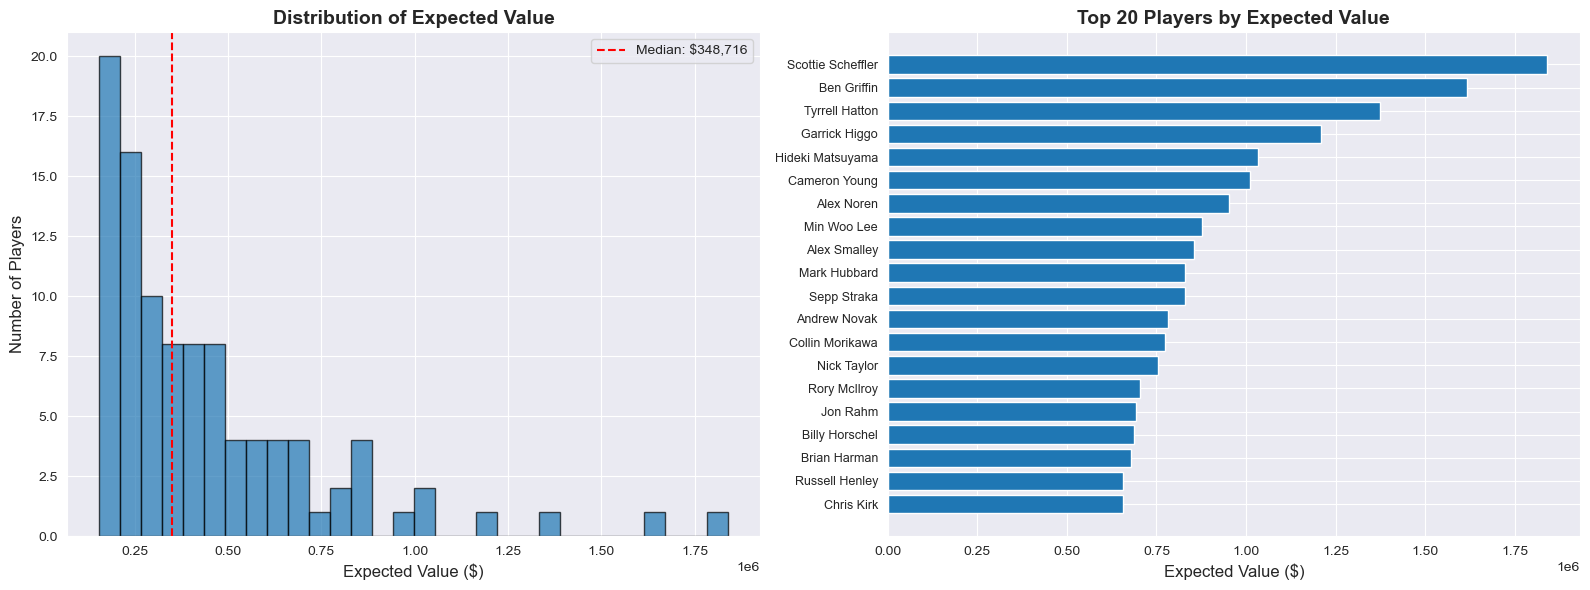


💡 The EV distribution shows clear tiers of players!
Top tier (>$300k EV): 58 players
Mid tier ($100-300k EV): 42 players


In [11]:
# Get EV for all available players
all_recommendations = get_weekly_recommendations(
    field_df=latest_form,
    purse=20_000_000,
    tournament_type="Elevated",
    usage_tracker=UsageTracker(),  # Fresh tracker
    rf_win_model=rf_win,
    rf_top5_model=rf_top5,
    top_n=100
)

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Distribution of EV
axes[0].hist(all_recommendations['expected_value'], bins=30, edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Expected Value ($)', fontsize=12)
axes[0].set_ylabel('Number of Players', fontsize=12)
axes[0].set_title('Distribution of Expected Value', fontsize=14, fontweight='bold')
axes[0].axvline(all_recommendations['expected_value'].median(), color='red', linestyle='--', 
                label=f'Median: ${all_recommendations["expected_value"].median():,.0f}')
axes[0].legend()

# Top 20 players by EV
top_20 = all_recommendations.head(20)
axes[1].barh(range(len(top_20)), top_20['expected_value'])
axes[1].set_yticks(range(len(top_20)))
axes[1].set_yticklabels(top_20['player_name'], fontsize=9)
axes[1].set_xlabel('Expected Value ($)', fontsize=12)
axes[1].set_title('Top 20 Players by Expected Value', fontsize=14, fontweight='bold')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

print("\n💡 The EV distribution shows clear tiers of players!")
print(f"Top tier (>$300k EV): {(all_recommendations['expected_value'] > 300000).sum()} players")
print(f"Mid tier ($100-300k EV): {((all_recommendations['expected_value'] >= 100000) & (all_recommendations['expected_value'] <= 300000)).sum()} players")

## 🎯 Summary & Next Steps

### What You've Built:
1. ✅ **Weekly recommendation engine** that ranks golfers by Expected Value
2. ✅ **Usage tracking system** that enforces 3-use limit per player
3. ✅ **Integration** of prize money (Phase 1) + predictions (Phase 2)
4. ✅ **Production-ready tool** you can use every week!

### How to Use This for Your League:

**Every Thursday:**
1. Get the tournament field (player list)
2. Find each player's latest stats in your database
3. Run `get_weekly_recommendations()` with:
   - Field data
   - Tournament purse (check PGA Tour site)
   - Tournament type (Major/Elevated/Regular)
   - Your current usage tracker
4. Pick the top 3 + alternate
5. Record your picks with `usage_tracker.use_player()`

### Enhancements to Consider:
- **Course history**: Add player-specific venue performance when you get multi-year data
- **Weather adjustments**: Wind/rain favors certain skill sets
- **Ownership %**: In DFS, you want low-owned boom/bust players
- **Correlation**: Don't pick 3 similar players (diversify risk)

### Next Phase:
**Phase 3B: Season-Long Optimizer**
- Plan all 30 weeks in advance
- When to use elite golfers (save Scheffler for majors?)
- Optimal allocation strategy
- What-if scenarios

**Ready to build the optimizer?**

In [12]:
# Save your usage tracker for the season
import json

def save_usage_tracker(tracker, filename='usage_tracker.json'):
    with open(filename, 'w') as f:
        json.dump(tracker.usage, f)
    print(f"✅ Usage tracker saved to {filename}")

def load_usage_tracker(filename='usage_tracker.json'):
    tracker = UsageTracker()
    try:
        with open(filename, 'r') as f:
            tracker.usage = json.load(f)
        print(f"✅ Usage tracker loaded from {filename}")
    except FileNotFoundError:
        print("No saved tracker found. Starting fresh.")
    return tracker

# Test save/load
save_usage_tracker(my_tracker)
loaded_tracker = load_usage_tracker()
print("\nLoaded usage:")
print(loaded_tracker.get_summary())

✅ Usage tracker saved to usage_tracker.json
✅ Usage tracker loaded from usage_tracker.json

Loaded usage:
              player  times_used  remaining
0  Scottie Scheffler           1          2
1        Ben Griffin           1          2
2     Tyrrell Hatton           1          2
